# Ungraded Lab: Building Visualizations Lab

## Overview 
In this hands-on lab, you'll create and enhance data visualizations using both Matplotlib and Seaborn libraries. Working with the EngageMetrics employee dataset, you'll learn how to build effective visualizations and improve their clarity through parameter adjustments. This lab reinforces core visualization concepts while preparing you for real-world data presentation scenarios. Remember that the lesson screencast is there to support your learning journey. Having the video open in another tab for quick reference is a strategy used by professionals and learners alike.

## Learning Outcomes 
By the end of this lab, you will be able to:
- Create basic plots using Matplotlib
- Enhance visualizations using Seaborn
- Adjust visualization parameters for improved clarity
- Build and customize scatter plots with regression lines

## Dataset Information 
We'll use the <b>employee_insights.csv</b> dataset from EngageMetrics, containing employee performance metrics, satisfaction scores, and workplace information.

## Activities

### Activity 1: Basic Matplotlib Visualization
<b>Step 1:</b> Set up your environment and load the data:

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
df = pd.read_csv('employee_insights.csv')

<b>Step 2: Try It Yourself:</b> Create a basic line plot:

department
Engineering    6.647059
Finance        5.318182
Hr             4.000000
Marketing      5.285714
Name: satisfaction_score, dtype: float64


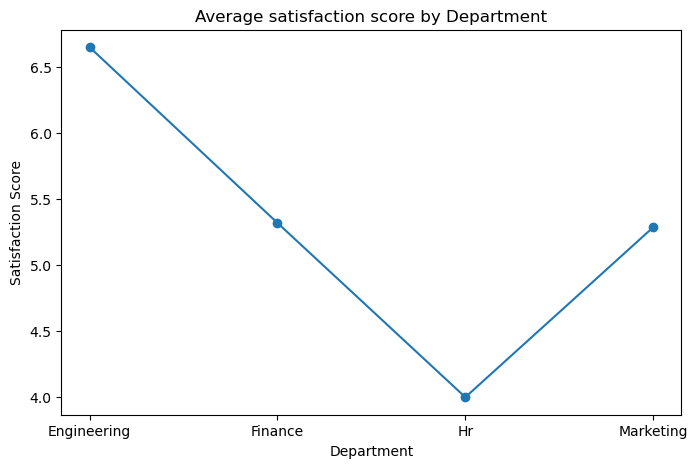

In [2]:
# Create a line plot showing average satisfaction scores by department, after cleaning and consolidating 
# the department column.

# Standardize department names
df['department'] = df['department'].str.capitalize()

# Calculate average satisfaction scores by department
dept_satisfaction = df.groupby('department')['satisfaction_score'].mean()
print(dept_satisfaction)

# Create a basic line plot
plt.figure(figsize=(8, 5))
plt.plot(dept_satisfaction.index, dept_satisfaction.values, marker='o')
plt.title('Average satisfaction score by Department')
plt.xlabel('Department')
plt.ylabel('Satisfaction Score')
plt.show()

<b>Tip:</b> Use plt.plot() and remember to clean department column data. Remember to call plt.show() to display your visualization

### Activity 2: Enhancing with Seaborn
<b>Step 1:</b> Create an enhanced scatter plot:

In [3]:
# Clean the work_experience column to ensure it contains only numeric values.
# Create a scatter plot of work experience vs satisfaction score. Use Seaborn's scatterplot function.

df['work_experience'] = df['work_experience'].str.extract(r'(\d+\.?\d*)').fillna(0).astype(int)
print("Work Experience:\n", df['work_experience'].head())
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].mean()).astype(float)
print("satisfaction score:\n", df['satisfaction_score'].head())

Work Experience:
 0     0
1     1
2     8
3    16
4     0
Name: work_experience, dtype: int64
satisfaction score:
 0     5.57377
1     5.57377
2    10.00000
3     5.00000
4     5.57377
Name: satisfaction_score, dtype: float64


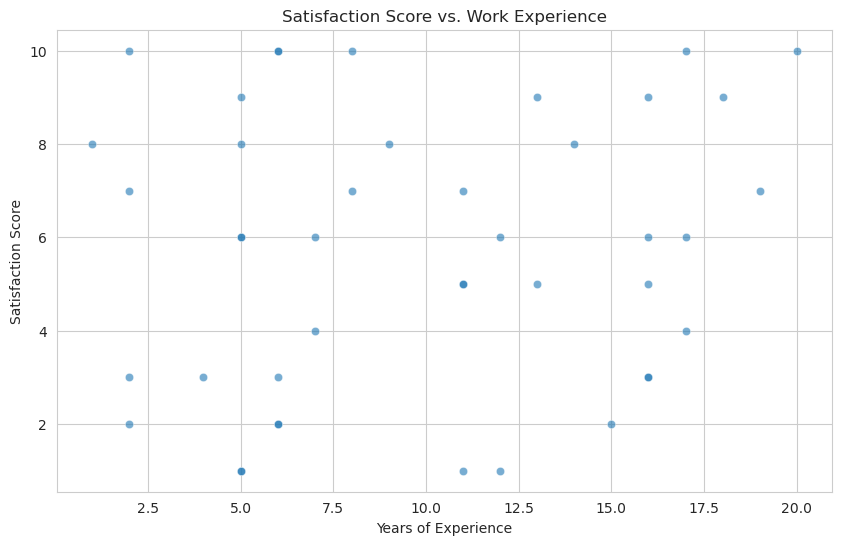

In [9]:
# Create a simple scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, 
                x='work_experience',
                y='satisfaction_score',
                alpha=0.6)
plt.title('Satisfaction Score vs. Work Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Satisfaction Score')
plt.show()


<b>Step 2:</b> Add a regression line:

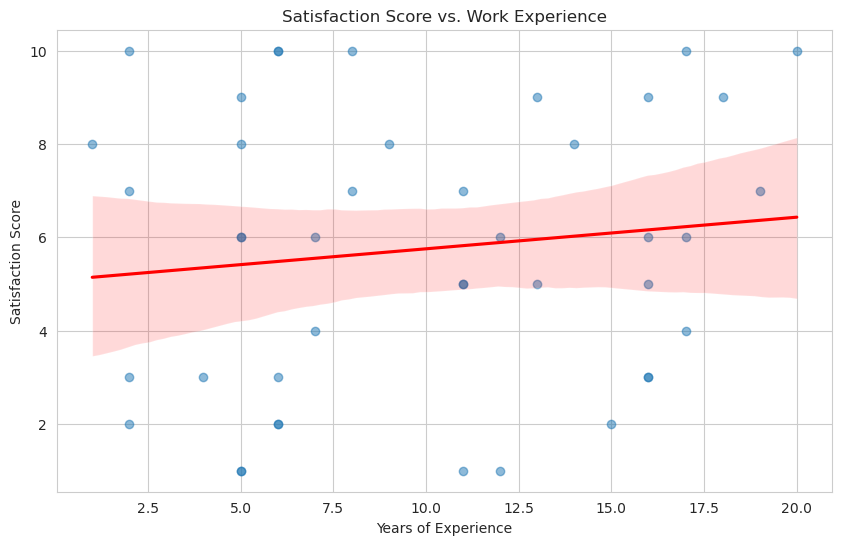

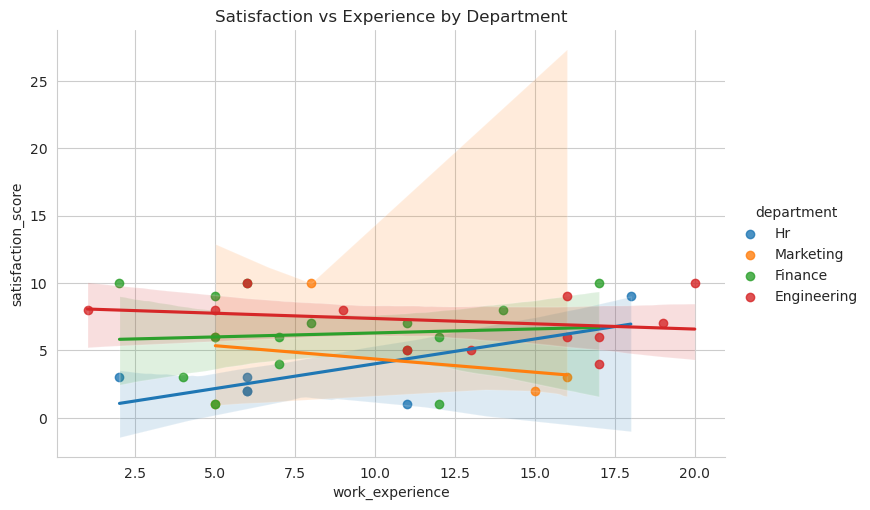

In [11]:
# Enhance the scatter plot with a regression line

# Create a regression plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df,
            x='work_experience',
            y='satisfaction_score',
            scatter_kws={'alpha':0.5},
            line_kws={'color': 'red'})
plt.title('Satisfaction Score vs. Work Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Satisfaction Score')
plt.show()

sns.lmplot(data=df, 
           x='work_experience', 
           y='satisfaction_score', 
           hue='department', 
           aspect=1.5)
plt.title('Satisfaction vs Experience by Department')
plt.show()

<b>Tip:</b> Use sns.regplot()

### Activity 3: Parameter Customization
<b>Step 1:</b> Customize your visualization to include:
- Use work experience as the x-axis and satisfaction score as the y-axis
- Color-code by department to spot differences across teams
- Scale point sizes by salary to add a third layer of information
- Include custom colors, labels, transparency, and a title for better readability

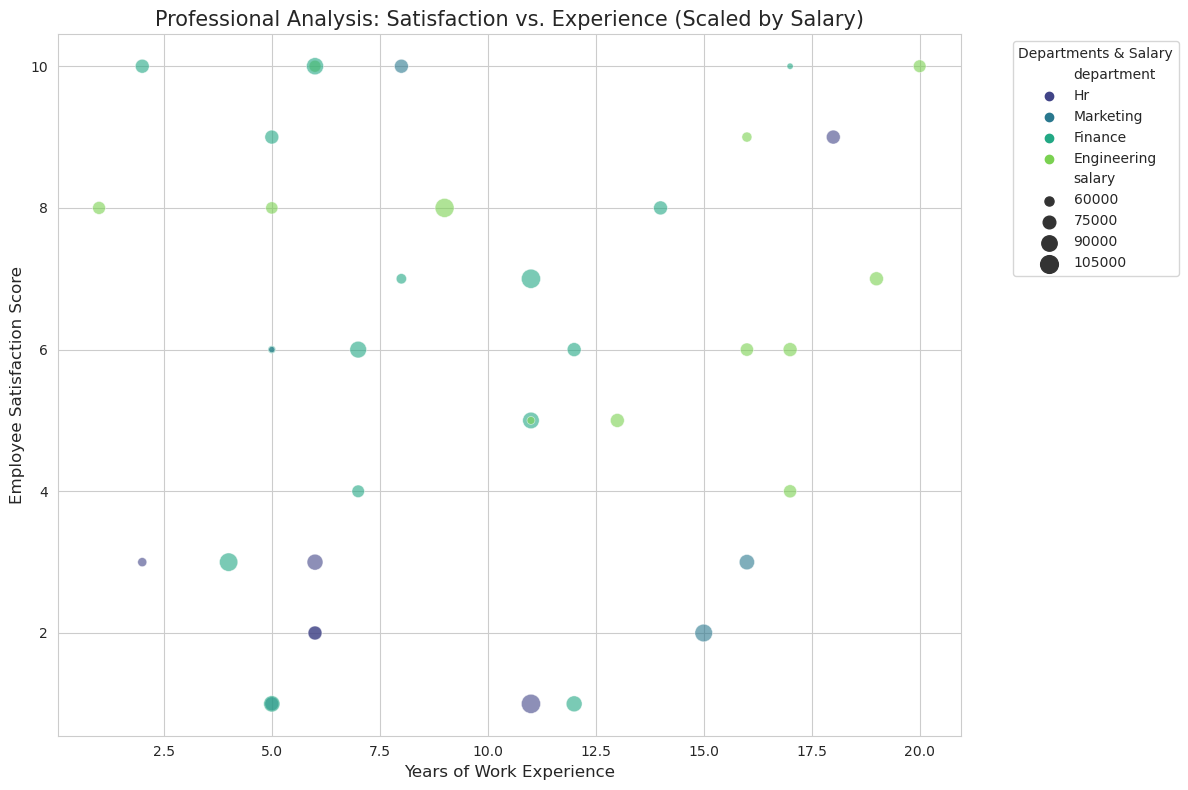

In [12]:
# Modify the plot's appearance (colors, size, labels)

# Configuramos el estilo y el tamaño de la figura
plt.figure(figsize=(12, 8))

# Creamos el gráfico de dispersión avanzado
sns.scatterplot(
    data=df,
    x='work_experience',
    y='satisfaction_score',
    hue='department',          # Capa 2: Color por departamento
    size='salary',             # Capa 3: Tamaño por salario
    sizes=(20, 200),           # Rango de tamaño de los puntos
    alpha=0.6,                 # Transparencia para ver puntos solapados
    palette='viridis'          # Colores personalizados (puedes usar 'magma', 'rocket', etc.)
)

# Personalización de etiquetas y títulos
plt.title('Professional Analysis: Satisfaction vs. Experience (Scaled by Salary)', fontsize=15)
plt.xlabel('Years of Work Experience', fontsize=12)
plt.ylabel('Employee Satisfaction Score', fontsize=12)

# Ajustamos la leyenda para que no tape los datos
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Departments & Salary')

plt.tight_layout()
plt.show()

<b>Test Your Work:</b> For each visualization:
1. Check that all axes are properly labeled
2.Verify that the plot is clearly readable
3. Ensure colors are appropriate for the data type
    
## Success Checklist
- Created basic Matplotlib visualization
- Successfully enhanced plots with Seaborn
- Added regression line to scatter plot
- Customized plot parameters effectively
- All visualizations are clearly labeled

## Common Issues & Solutions 
- Problem: Plot not displaying 
    - Solution: Ensure you've called plt.show()
- Problem: Regression line not appearing 
    - Solution: Check that you're using sns.regplot correctly

## Summary 
In this lab, you've practiced creating and enhancing data visualizations using both Matplotlib and Seaborn. You've learned how to improve plot clarity through parameter adjustments and add statistical elements like regression lines.

## Solution Code
Stuck on your code or want to check your solution? Here's a complete reference implementation to guide you. This represents just one effective approach—try solving independently first, then use this to overcome obstacles or compare techniques. The solution is provided to help you move forward and explore alternative approaches to achieve the same results. Happy coding!

### Activity 1: Basic Matplotlib Visualization - Solution Code

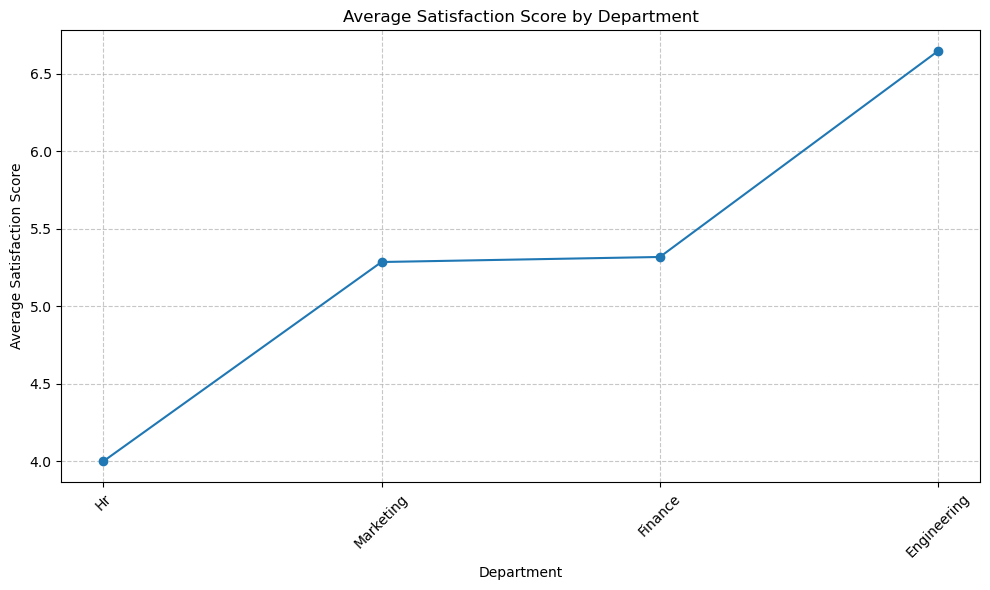

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('employee_insights.csv')

# Create line plot of average satisfaction by department
plt.figure(figsize=(10, 6))

# Consolidating the department column
df['department'] = df['department'].str.capitalize()


# Calculate average satisfaction by department
dept_satisfaction = df.groupby('department')['satisfaction_score'].mean().sort_values()

plt.plot(dept_satisfaction.index, dept_satisfaction.values, marker='o')
plt.title('Average Satisfaction Score by Department')
plt.xlabel('Department')
plt.ylabel('Average Satisfaction Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Activity 2: Enhancing with Seaborn - Solution Code

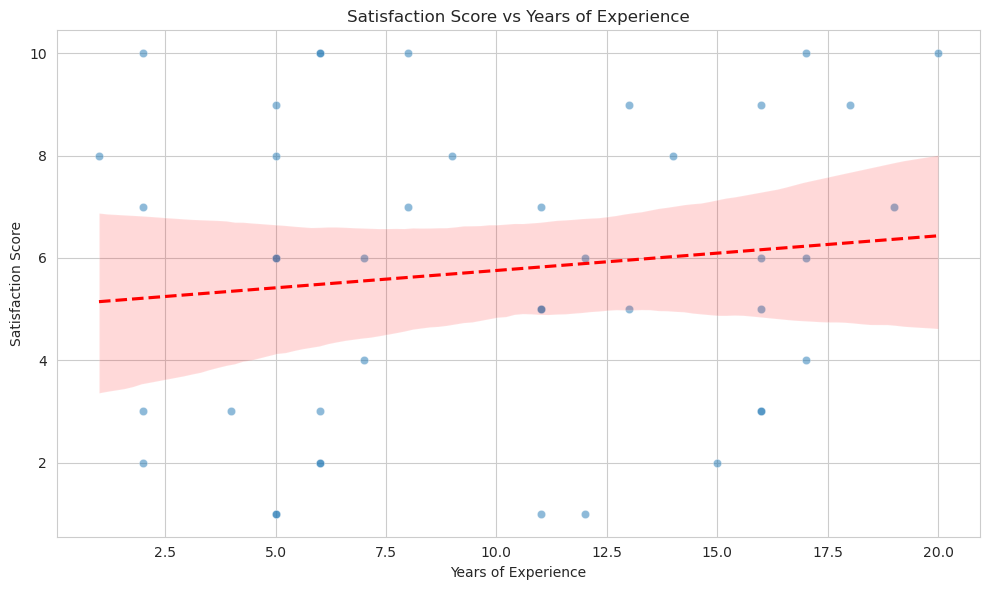

In [7]:
# Set Seaborn style
sns.set_style("whitegrid")

# Clean work_experience column
df['work_experience'] = (df['work_experience']
.astype(str)
.str.extract(r'(\d+\.?\d*)') .astype(float))

# Create enhanced scatter plot
plt.figure(figsize=(10, 6))

# Basic scatter plot
sns.scatterplot(data=df, 
                x='work_experience', 
                y='satisfaction_score',
                alpha=0.5)

# Add regression line
sns.regplot(data=df,
            x='work_experience',
            y='satisfaction_score',
            scatter=False,
            color='red',
            line_kws={'linestyle': '--'})

plt.title('Satisfaction Score vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Satisfaction Score')

plt.tight_layout()
plt.show()

### Activity 3: Parameter Customization  - Solution Code

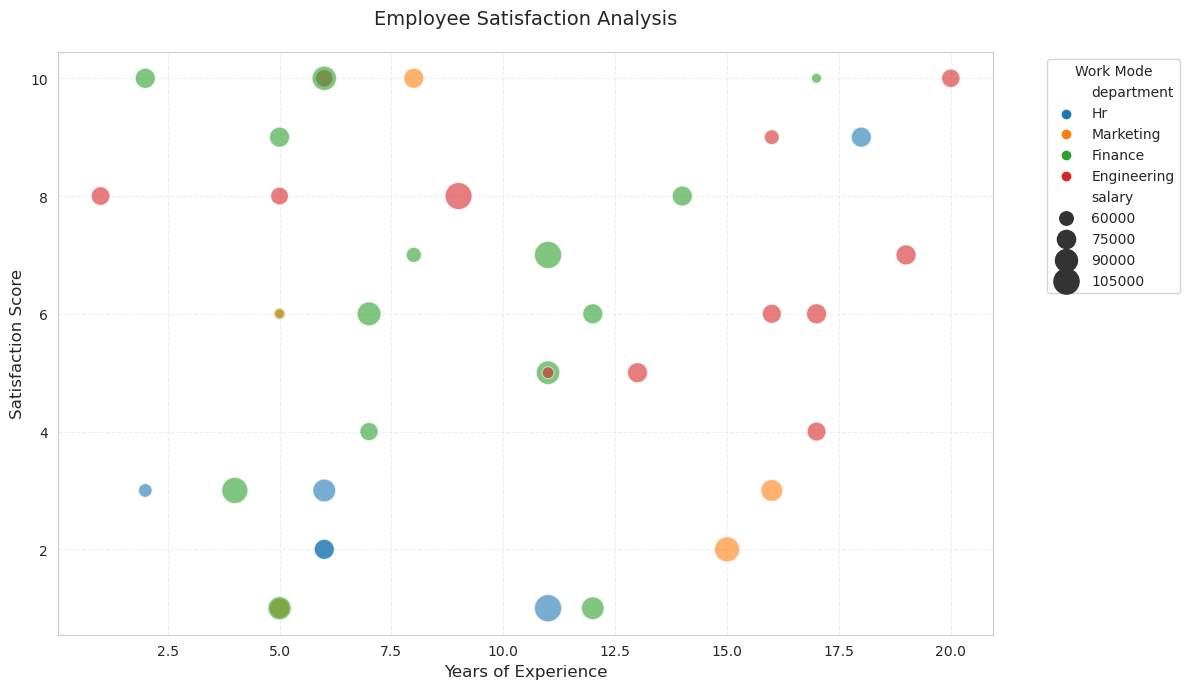

In [8]:
# Create customized visualization
plt.figure(figsize=(12, 7))

# Clean salary column
df['salary'] = (df['salary']
.str.replace("$","").astype(float))
df['salary'] = df['salary'].fillna(df['salary'].mean())


# Create scatter plot with additional features
sns.scatterplot(data=df,
                x='work_experience',
                y='satisfaction_score',
                hue='department',  # Color by work department
                size='salary',    # Size by salary
                sizes=(50, 400),  # Set size range
                alpha=0.6)        # Set transparency

# Customize the plot
plt.title('Employee Satisfaction Analysis', pad=20, size=14)
plt.xlabel('Years of Experience', size=12)
plt.ylabel('Satisfaction Score', size=12)

# Add a grid
plt.grid(True, linestyle='--', alpha=0.3)

# Customize legend
plt.legend(title='Work Mode', title_fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout
plt.tight_layout()
plt.show()